<!--TITLE: Свёртка и ReLU-->

In [13]:
import numpy as np
from itertools import product

In [14]:
def show_kernel(kernel, label=True, digits=None, text_size=28):

    # Форматирование ядра
    kernel = np.array(kernel)
    if digits is not None:
        kernel = kernel.round(digits)

    # Визуализация ядра
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max()+kernel.min())/2

    # Опционально: добавляем подписи значений
    if label:
        for i, j in product(range(rows), range(cols)):
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val, 
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

# Введение #

В прошлом уроке мы увидели, что свёрточный классификатор состоит из двух частей: свёрточной **базы** и **головы** из полносвязных слоёв. Мы узнали, что задача базы — извлекать визуальные признаки из изображения, которые голова затем использует для классификации.

В следующих нескольких уроках мы познакомимся с двумя важнейшими типами слоёв, которые обычно встречаются в базе свёрточного классификатора изображений. Это **свёрточный слой** с **активацией ReLU** и **слой максимального объединения**. В Уроке 5 вы узнаете, как проектировать собственную свёрточную сеть, компонуя эти слои в блоки, выполняющие извлечение признаков.

Этот урок посвящён свёрточному слою и его функции активации ReLU.

# Извлечение признаков #

Прежде чем углубляться в детали свёртки, давайте обсудим *назначение* этих слоёв в сети. Мы увидим, как три операции (свёртка, ReLU и максимальное объединение) используются для реализации процесса извлечения признаков.

**Извлечение признаков**, выполняемое базой, состоит из **трёх базовых операций**:

1. **Фильтрация** изображения на предмет определённого признака (свёртка)
2. **Обнаружение** этого признака в отфильтрованном изображении (ReLU)
3. **Сжатие** изображения для усиления признаков (максимальное объединение)

На следующем рисунке проиллюстрирован этот процесс. Вы можете видеть, как эти три операции позволяют изолировать некоторую конкретную характеристику исходного изображения (в данном случае — горизонтальные линии).

<figure>
<img src="./img/IYO9lqp.png" width="600" alt="Пример процесса извлечения признаков.">
<figcaption style="textalign: center; font-style: italic"><center>Три шага извлечения признаков.</center></figcaption>
</figure>

Обычно сеть выполняет несколько извлечений параллельно на одном изображении. В современных свёрточных сетях нередко финальный слой базы генерирует более 1000 уникальных визуальных признаков.

# Фильтрация с помощью свёртки #

Свёрточный слой выполняет шаг фильтрации. Вы можете определить свёрточный слой в модели Keras примерно так:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3), # activation is None
    # Далее следуют другие слои
])

Мы можем понять эти параметры, взглянув на их связь с *весами* и *активациями* слоя. Давайте сделаем это сейчас.

## Веса ##

**Веса**, которые свёрточная сеть изучает во время обучения, в основном содержатся в её свёрточных слоях. Эти веса мы называем **ядрами (kernels)**. Их можно представить в виде небольших массивов:

<figure>
<img src="./img/uJfD9r9.png" width="150" alt="Ядро 3x3.">
</figure>

Ядро работает, сканируя изображение и вычисляя *взвешенную сумму* значений пикселей. Таким образом, ядро действует как поляризованная линза, подчёркивая или приглушая определённые информационные паттерны.

<figure>
<img src="./img/j3lk26U.png" width="250" alt="Ядро действует как линза.">
<figcaption style="textalign: center; font-style: italic"><center>Ядро действует как линза.</center></figcaption>
</figure>

Ядра определяют, как свёрточный слой соединён со следующим слоем. Приведённое выше ядро соединяет каждый нейрон на выходе с девятью нейронами на входе. Задавая размеры ядер через `kernel_size`, вы указываете свёрточной сети, как формировать эти соединения. Чаще всего ядро имеет нечётные размеры — например, `kernel_size=(3, 3)` или `(5, 5)` — чтобы один пиксель находился в центре, но это не обязательное требование.

Ядра в свёрточном слое определяют, какие типы признаков он создаёт. Во время обучения свёрточная сеть пытается выучить, какие признаки ей нужны для решения задачи классификации. Это означает поиск наилучших значений для своих ядер.

## Активации ##

**Активации** в сети мы называем **картами признаков (feature maps)**. Это результат применения фильтра к изображению; они содержат визуальные признаки, извлечённые ядром. Ниже показаны несколько ядер вместе с картами признаков, которые они создают.

<figure>
<img src="./img/JxBwchH.png" width="800" alt="Три ядра и создаваемые ими карты признаков.">
<figcaption style="textalign: center; font-style: italic"><center>Ядра и признаки.</center></figcaption>
</figure>

По числовому паттерну в ядре можно определить, какие карты признаков оно создаёт. В общем случае, то, что свёртка подчёркивает во входных данных, соответствует форме *положительных* чисел в ядре. Левое и среднее ядра выше оба фильтруют горизонтальные формы.

С помощью параметра `filters` вы указываете свёрточному слою, сколько карт признаков он должен создать на выходе.

# Обнаружение с помощью ReLU #

После фильтрации карты признаков проходят через функцию активации. **Функция выпрямителя (rectifier)** имеет следующий график:

<figure>
<img src="./img/DxGJuTH.png" width="300" alt="График функции активации ReLU.">
<figcaption style="textalign: center; font-style: italic"><center>График функции выпрямителя похож на линию, у которой отрицательная часть «выпрямлена» до 0.</center></figcaption>
</figure>

Нейрон с присоединённым выпрямителем называется *выпрямленным линейным элементом (Rectified Linear Unit)*. По этой причине функцию выпрямителя также называют **активацией ReLU** или просто функцией ReLU.

Активацию ReLU можно определить в отдельном слое `Activation`, но чаще всего её просто включают как функцию активации слоя `Conv2D`.

In [ ]:
model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation='relu')
    # Далее следуют другие слои
])

Можно рассматривать функцию активации как оценку значений пикселей по некоторой мере важности. Активация ReLU говорит, что отрицательные значения не важны, и обнуляет их («Всё неважное одинаково неважно»).

Вот как ReLU применяется к картам признаков, показанным выше. Обратите внимание, как ей удаётся изолировать признаки.

<figure>
<img src="./img/dKtwzPY.png" width="800" alt="ReLU, применённая к картам признаков.">
</figure>

Как и другие функции активации, функция ReLU является **нелинейной**. По сути это означает, что суммарный эффект всех слоёв сети становится иным, чем если бы мы просто складывали эффекты — что было бы равносильно тому, чего можно достичь с помощью всего одного слоя. Нелинейность гарантирует, что признаки будут комбинироваться интересными способами по мере продвижения вглубь сети. (Мы подробнее рассмотрим это «накопление признаков» в Уроке 5.)

# Пример — применение свёртки и ReLU #

В этом примере мы самостоятельно выполним извлечение, чтобы лучше понять, что свёрточные сети делают «за кулисами».

Вот изображение, которое мы будем использовать:

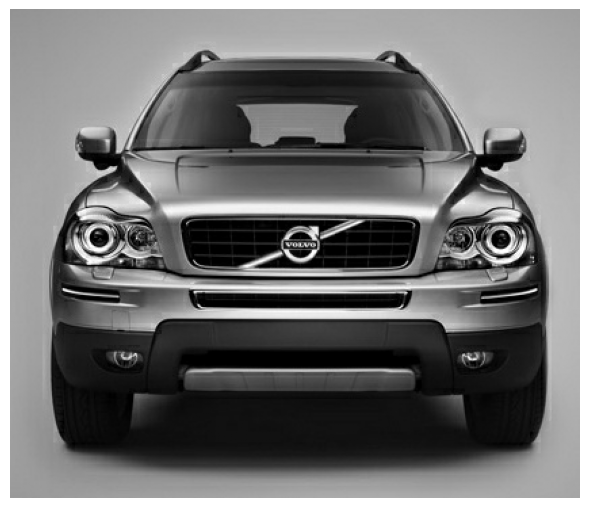

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image_path = './img/car_feature.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.show();

Для шага фильтрации мы определим ядро, а затем применим его с помощью свёртки. В данном случае ядро — это ядро «обнаружения границ». Его можно определить с помощью `tf.constant` так же, как вы определяете массив в Numpy с помощью `np.array`. Это создаёт *тензор* того типа, который использует TensorFlow.

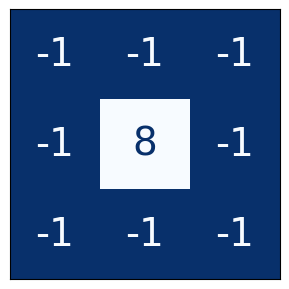

In [16]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])



plt.figure(figsize=(3, 3))
show_kernel(kernel)

TensorFlow включает множество распространённых операций, используемых нейронными сетями, в своём модуле `tf.nn`. Две из них, которые мы будем использовать — `conv2d` и `relu`. Это просто функциональные версии слоёв Keras.

Следующая скрытая ячейка выполняет некоторое переформатирование для совместимости с TensorFlow. Детали не важны для этого примера.

In [17]:
# Переформатирование для совместимости с пакетной обработкой
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

Теперь применим наше ядро и посмотрим, что получится.

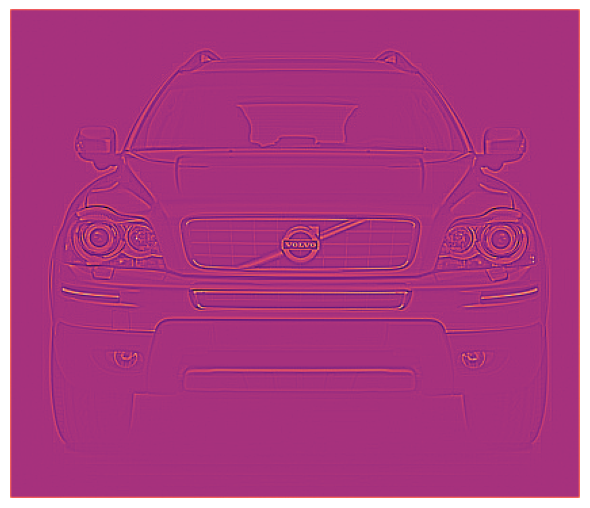

In [18]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    # мы поговорим об этих двух параметрах в уроке 4!
    strides=1,
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

Далее следует этап обнаружения с помощью функции ReLU. Эта функция намного проще свёртки, так как не имеет настраиваемых параметров.

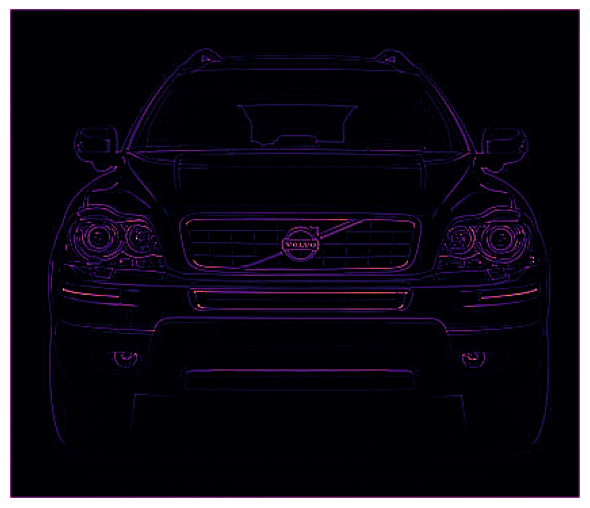

In [19]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();

И вот мы создали карту признаков! Такие изображения голова использует для решения задачи классификации. Можно представить, что одни признаки могут быть более характерны для *Автомобилей*, а другие — для *Грузовиков*. Задача свёрточной сети во время обучения — создать ядра, способные находить эти признаки.

# Заключение #

В этом уроке мы рассмотрели первые два шага, которые свёрточная сеть использует для извлечения признаков: **фильтрацию** с помощью слоёв `Conv2D` и **обнаружение** с помощью активации `relu`.

# Ваша очередь #

В [**упражнениях**](https://www.kaggle.com/kernels/fork/11989557) у вас будет возможность поэкспериментировать с ядрами предобученной модели VGG16, которую мы использовали в Уроке 1.

---

*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*